      Player Name  Rounds  Fairway Percentage  Year  Avg Distance    gir  \
0  Henrik Stenson    60.0               75.19  2018         291.5  73.51   
1     Ryan Armour   109.0               73.58  2018         283.5  68.22   
2     Chez Reavie    93.0               72.24  2018         286.5  68.67   
3      Ryan Moore    78.0               71.94  2018         289.2  68.80   
4    Brian Stuard   103.0               71.44  2018         278.9  67.12   

   Average Putts  Average Scrambling  Average Score Points  Wins  Top 10  \
0          29.93               60.67         69.617    868   NaN     5.0   
1          29.31               60.13         70.758  1,006   1.0     3.0   
2          29.12               62.27         70.432  1,020   NaN     3.0   
3          29.17               64.16         70.015    795   NaN     5.0   
4          29.11               59.23         71.038    421   NaN     3.0   

   Average SG Putts  Average SG Total  SG:OTT  SG:APR  SG:ARG       Money  
0         

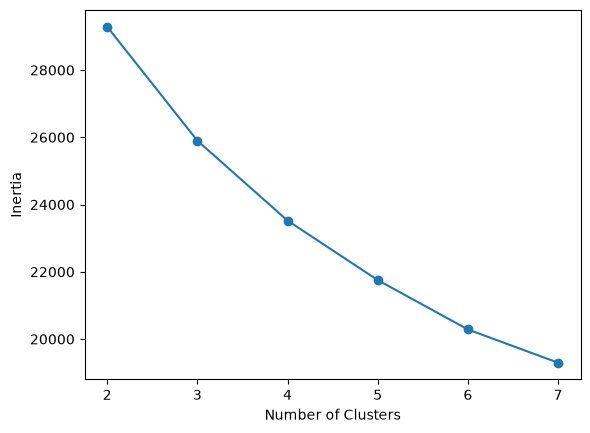

            Rounds  Fairway Percentage         Year  Avg Distance        gir  \
Cluster                                                                        
0        67.918367           58.817526  2013.826531    287.978316  62.897372   
1        84.192208           61.357091  2014.349741    295.049351  66.903247   
2        81.065483           62.617436  2013.950456    290.226193  66.333818   

         Average Putts  Average Scrambling  Average Score      Wins    Top 10  \
Cluster                                                                         
0            29.159566           55.966378      71.764666  1.000000  1.458937   
1            28.893818           60.536156      70.062704  1.376543  5.130208   
2            29.280133           58.016426      70.922486  1.028037  2.057670   

         Average SG Putts  Average SG Total    SG:OTT    SG:APR    SG:ARG  
Cluster                                                                    
0               -0.043768         -0.6997

/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5737/656125035.py:41: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text = df.select_dtypes(include="object").iloc[:, 0].fillna("")
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5737/656125035.py:50: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https

In [1]:
# 1. Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer

# 2. Load data
df = pd.read_csv("pgaTourData.csv")
print(df.head())
print(df.info())

# 3. K-Means: numerical data
num = df.select_dtypes(include=np.number).columns
X = df[num].fillna(df[num].median())

# Scale data
X = StandardScaler().fit_transform(X)

# 4. Find K using Elbow Method
inertia = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.plot(range(2, 8), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

# 5. K-Means clustering
km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["Cluster"] = km.fit_predict(X)

# Show clusters
print(df.groupby("Cluster")[num].mean())

# 6. NLP
text = df.select_dtypes(include="object").iloc[:, 0].fillna("")

tfidf = TfidfVectorizer(stop_words="english")
T = tfidf.fit_transform(text)

# NLP K-Means
nlp_km = KMeans(n_clusters=3, random_state=42, n_init=10)
df["NLP_Cluster"] = nlp_km.fit_predict(T)

print(df[[df.select_dtypes(include="object").columns[0],
          "NLP_Cluster"]].head())

# 7. Save results
df.to_csv("pgaTourData_results.csv", index=False)

print("Done!")